In [ ]:
import numpy as np
from numpy import exp, loadtxt, pi, sqrt
from scipy import stats
from scipy.stats import binned_statistic 
from astropy.table import Table, Column, MaskedColumn
import math
import matplotlib.pyplot as plte
import pylab
from astropy.io import ascii
import pickle
import pandas as pd
import os.path
from numpy import exp, loadtxt, pi, sqrt

In [5]:
import haloscope
print(haloscope.__file__)


ModuleNotFoundError: No module named 'haloscope'

In [2]:
def am(val):
    return (val[1:]+val[:-1])/2

from scipy import interpolate
def confidence_intervals(z,dx=1,dy=1):
    """
    takes normalised probability distribution as input (fi dx,dy=1 then probdist=n/Ntotal)
    outputs the level of the contour at which 75% 50% and 25%
    """
    n = 20
    t = np.linspace(0, z.max(), n)
    integral = ((z >= t[:, None, None]) * z).sum(axis=(1,2)) *dx*dy
    f = interpolate.interp1d(integral, t)
    t_contours = f(np.array([0.95,0.68,0.40]))
    return np.append(t_contours,1)

In [3]:
nsim = 27
lista_columns = ['id','pid','x','y','z','M200b'] 

path = 'Data/Rockstar/IllustrisTNG/L25n256/CV/CV_'
for i in range(nsim):
    if i == 0:
        data_bar = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=63, sep='\s+', names=lista_columns, 
                         usecols=(1,5,17,18,19,39), low_memory=False)
    if i > 0: 
        data_aux = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=63, sep='\s+', names=lista_columns, 
                         usecols=(1,5,17,18,19,39), low_memory=False)
        data_bar = pd.concat([data_bar, data_aux])

FileNotFoundError: [Errno 2] No such file or directory: 'Data/Rockstar/IllustrisTNG/L25n256/CV/CV_0/hlists/hlist_1.00000.list'

In [4]:
nsim = 27
lista_columns = ['id','pid','x','y','z','M200b']
path = 'Data/Rockstar/IllustrisTNG_DM//L25n256/CV/CV_'
for i in range(nsim):
    if i == 0:
        data_dm = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=64, sep='\s+', names=lista_columns, 
                         usecols=(1,5,17,18,19,39), low_memory=False)
    if i > 0: 
        data_aux = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=64, sep='\s+', names=lista_columns, 
                         usecols=(1,5,17,18,19,39), low_memory=False)
        data_dm = pd.concat([data_dm, data_aux])

FileNotFoundError: [Errno 2] No such file or directory: 'Data/Rockstar/IllustrisTNG_DM//L25n256/CV/CV_0/hlists/hlist_1.00000.list'

In [12]:
# Mass 'correction'
halos_bar = data_bar[(data_bar.pid == -1)]
halos_dm = data_dm[(data_dm.pid == -1)]
#########################
import scipy
lr_ind = np.asarray(halos_dm.id)
data_hr = halos_bar[['x','y','z']].values
data_lr = halos_dm[['x','y','z']].values
tree_lr = scipy.spatial.KDTree(data_lr,boxsize=25.000000)
distance,results= tree_lr.query(data_hr, k=10, eps=0, p=2, distance_upper_bound=5, workers=5)
m200bhr = np.asarray(halos_bar.M200b)
m200blr = np.asarray(halos_dm.M200b)

In [18]:
len(m200bhr)-len(m200blr),len(m200bhr),len(m200blr),(len(m200bhr)-len(m200blr))*100/len(m200bhr)

(5502, 169656, 164154, 3.2430329608148254)

In [19]:
#match_me_uniquely

def match_me_uniquely(count,lr_ind,distance,results):
    for i in range(0,10):
        if int(lr_ind[i])==(len(data_lr)):
            break
        else:
            delM = np.abs((m200bhr[count]-m200blr[int(lr_ind[i])])/(m200bhr[count]))
            if (np.isnan(match_for_lr[int(lr_ind[i]),0])) & (delM < 0.95): ## if there is "NO" hr halo to which this lr halo has been matched previously
                match_for_hr[count] = int(lr_ind[i])
                match_for_lr[int(lr_ind[i]),0] = count
                match_for_lr[int(lr_ind[i]),1] = distance[count][i]  ## assign distance to the lr sized array that stores hr index and distance
                break
            else:## if there is a hr halo to which this lr halo has been matched previously
                if (match_for_lr[int(lr_ind[i]),1]>distance[count][i])&(delM<0.95):
                    match_for_hr[int(match_for_lr[int(lr_ind[i]),0])] = np.nan ## unmatch the previous hr halo
                    match_for_hr[count] = int(lr_ind[i])                       ## match the new hr halo
                    old_count_hr = match_for_lr[int(lr_ind[i]),0]
                    match_for_lr[int(lr_ind[i]),0] = count                     ## rewrite the new lr match
                    match_for_lr[int(lr_ind[i]),1] = distance[count][i]        ## rewrite the distance to the new match
                    match_me_uniquely(int(old_count_hr),results[int(old_count_hr)],distance,results)## find the previous hr match a new lr match (hopefully)
                    break
match_for_hr = np.nan*np.ones([len(data_hr)])
match_for_lr = np.nan*np.ones([len(data_lr),2])
for count,lr_ind in enumerate(results):
    match_me_uniquely(count,lr_ind,distance,results)
match_for_hr_3d = np.copy(match_for_hr)
match_for_lr_3d = np.copy(match_for_lr)

In [20]:
count,len(results),len(m200bhr),len(m200blr)

(169655, 169656, 169656, 164154)

In [21]:
lnnewm200b = np.zeros(len(m200blr))
boolarray = np.zeros(len(m200blr))
for i in range(len(m200blr)):
    if np.isnan(match_for_lr_3d[i,0])==False:
        lnnewm200b[i] = m200bhr[int(match_for_lr_3d[i,0])]
        boolarray[i] = 1

In [22]:
lnnewm200b.shape,lnnewm200b

((164154,),
 array([5.7599e+13, 2.7568e+13, 2.6475e+13, ..., 6.0339e+09, 2.9196e+09,
        4.9958e+09]))

In [54]:
lnnewm200b[lnnewm200b != 0]
len(lnnewm200b)

5958

In [23]:
nsim = 27
lista_columns = ['id','pid','Rvir','x','y','z','Spin','Rs_Klypin','M200b','ba','ca','ba500c','ca500c','Vpeak','TidalForce'] 

path = 'Data/Rockstar/IllustrisTNG/L25n256/CV/CV_'
for i in range(nsim):
    if i == 0:
        data_bar = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=63, sep='\s+', names=lista_columns, 
                         usecols=(1,5,11,17,18,19,26,37,39,46,47,51,52,66,81), low_memory=False)
    if i > 0: 
        data_aux = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=63, sep='\s+', names=lista_columns, 
                         usecols=(1,5,11,17,18,19,26,37,39,46,47,51,52,66,81), low_memory=False)
        data_bar = pd.concat([data_bar, data_aux])
  

cv = data_bar.Rvir / data_bar.Rs_Klypin
data_bar.insert(9,'cv', cv) 

In [25]:
nsim = 27
lista_columns = ['id','pid','Rvir','x','y','z','Spin','Rs_Klypin','M200b','ba','ca','ba500c','ca500c','Vpeak','TidalForce'] 
path = 'Data/Rockstar/IllustrisTNG_DM//L25n256/CV/CV_'
for i in range(nsim):
    if i == 0:
        data_dm = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=64, sep='\s+', names=lista_columns, 
                         usecols=(1,5,11,17,18,19,26,37,39,46,47,51,52,63,78), low_memory=False)
    if i > 0: 
        data_aux = pd.read_table(path + str(i) + '/hlists/hlist_1.00000.list', index_col=False, header=64, sep='\s+', names=lista_columns, 
                         usecols=(1,5,11,17,18,19,26,37,39,46,47,51,52,63,78), low_memory=False)
        data_dm = pd.concat([data_dm, data_aux])
  

cv = data_dm.Rvir / data_dm.Rs_Klypin
newM200b = lnnewm200b
data_dm.insert(10,'cv', cv)

In [92]:
halos_bar = data_bar[(data_bar.pid == -1)]
halos_dm = data_dm[(data_dm.pid == -1)]
len(halos_bar),len(halos_dm)

(169656, 164154)

In [27]:
#HMF Baryon Halos
halos_bar = data_bar[(data_bar.pid == -1)]
min_mass_hbar = halos_bar.M200b.min()
max_mass_hbar = halos_bar.M200b.max()
max_halo_mass_bar = max_mass_hbar
min_npart_for_mf_bar = min_mass_hbar 
limits_hbar = [np.log10(min_npart_for_mf_bar), np.log10(max_halo_mass_bar)]
print(min_npart_for_mf_bar,max_halo_mass_bar)
############
#many files bar
import os.path
from numpy import exp, loadtxt, pi, sqrt
name_s =[]
path = 'Data/Rockstar/IllustrisTNG/L25n256/CV/'
lista_columns = ['id','pid','x','y','z','M200b']  
nsim=np.arange(27)
for i in nsim:
    name_s.append(path+'CV_'+str(i)+'/hlists/'+'hlist_1.00000.list')
num_mf_bins = 20
shape = num_mf_bins
aaa = np.array([])
bbb = np.array([])
nm_sim = len(name_s)
for i in range(0,nm_sim): 
    dh = pd.read_table(name_s[i],index_col=False,header=63,sep='\s+',names=lista_columns,usecols=(1,5,17,18,19,39),low_memory=False)
    halos_bar = dh[(dh.pid == -1) & (dh.M200b > 0)]
    meanHbars = stats.binned_statistic(np.log10(halos_bar.M200b),np.log10(halos_bar.M200b),statistic='mean', bins=shape, range=(limits_hbar[0],limits_hbar[1]))
    meanHbar = meanHbars[0]
    aaa = np.concatenate((aaa,meanHbar))
    countHbars = stats.binned_statistic(np.log10(halos_bar.M200b),np.log10(halos_bar.M200b),statistic='count', bins=shape,range=(limits_hbar[0],limits_hbar[1]))
    count = countHbars[0]
    bbb = np.concatenate((bbb,count))
means_sims_bar= np.array(aaa.reshape(nm_sim,shape))
counts_sims_bar = np.array(bbb.reshape(nm_sim,shape))

mfbinsmean_Hbar = np.nanmean(means_sims_bar,axis=0)
countHbar = counts_sims_bar.mean(0)

129760000 161660000000000


In [87]:
import scipy
#HMF DM Halos
halos_dm = data_dm[(data_dm.pid == -1)]
min_mass_hdm = halos_dm.M200b.min()
max_mass_hdm = halos_dm.M200b.max()
max_halo_mass_dm = max_mass_hdm
min_npart_for_mf_dm = min_mass_hdm 
limits_hdm = [np.log10(min_npart_for_mf_dm), np.log10(max_halo_mass_dm)]
print(min_npart_for_mf_dm,max_halo_mass_dm)
############
#many files dm
import os.path
from numpy import exp, loadtxt, pi, sqrt
name_s =[]
name_s_bar =[]
nsim=np.arange(27)
path = 'Data/Rockstar/IllustrisTNG_DM/L25n256/CV/'
path_bar = 'Data/Rockstar/IllustrisTNG/L25n256/CV/'
lista_columns = ['id','pid','x','y','z','M200b']  
for i in nsim:
    name_s.append(path+'CV_'+str(i)+'/hlists/'+'hlist_1.00000.list')
    name_s_bar.append(path_bar+'CV_'+str(i)+'/hlists/'+'hlist_1.00000.list')
num_mf_bins = 20
shape = num_mf_bins
aaa = np.array([])
bbb = np.array([])
new_aaa = np.array([])
new_bbb = np.array([])
nm_sim = len(name_s)
for i in range(0,nm_sim): 
    lnnewm200b =np.array([])
    dh = pd.read_table(name_s[i],index_col=False,header=64,sep='\s+',names=lista_columns,usecols=(1,5,17,18,19,39),low_memory=False)
    halos_dm = dh[(dh.pid == -1) & (dh.M200b > 0)]
    dh_bar = pd.read_table(name_s_bar[i],index_col=False,header=63,sep='\s+',names=lista_columns,usecols=(1,5,17,18,19,39),low_memory=False)
    halos_bar = dh_bar[(dh_bar.pid == -1) & (dh_bar.M200b > 0)]
    # Mass 'correction'
    lr_ind = np.asarray(halos_dm.id)
    data_hr = halos_bar[['x','y','z']].values
    nhs = len(data_hr) 
    #nhs = 10
    data_lr = halos_dm[['x','y','z']].values
    tree_lr = scipy.spatial.KDTree(data_lr,boxsize=25.000000)
    distance,results= tree_lr.query(data_hr, k=nhs, eps=0, p=2, distance_upper_bound=5, workers=5)
    m200bhr = np.asarray(halos_bar.M200b)
    m200blr = np.asarray(halos_dm.M200b)
    #match_me_uniquely
    def match_me_uniquely(count,lr_ind,distance,results):
        for ll in range(0,nhs):
            if int(lr_ind[ll])==(len(data_lr)):
                break
            else:
                delM = np.abs((m200bhr[count]-m200blr[int(lr_ind[ll])])/(m200bhr[count]))
                if (np.isnan(match_for_lr[int(lr_ind[ll]),0])) & (delM < 0.9): ## if there is "NO" hr halo to which this lr halo has been matched previously
                    match_for_hr[count] = int(lr_ind[ll])
                    match_for_lr[int(lr_ind[ll]),0] = count
                    match_for_lr[int(lr_ind[ll]),1] = distance[count][ll]  ## assign distance to the lr sized array that stores hr index and distance
                    break
                else:## if there is a hr halo to which this lr halo has been matched previously
                    if (match_for_lr[int(lr_ind[ll]),1]>distance[count][ll])&(delM<0.95):
                        match_for_hr[int(match_for_lr[int(lr_ind[ll]),0])] = np.nan ## unmatch the previous hr halo
                        match_for_hr[count] = int(lr_ind[ll])                       ## match the new hr halo
                        old_count_hr = match_for_lr[int(lr_ind[ll]),0]
                        match_for_lr[int(lr_ind[ll]),0] = count                     ## rewrite the new lr match
                        match_for_lr[int(lr_ind[ll]),1] = distance[count][ll]        ## rewrite the distance to the new match
                        match_me_uniquely(int(old_count_hr),results[int(old_count_hr)],distance,results)## find the previous hr match a new lr match (hopefully)
                        break
    match_for_hr = np.nan*np.ones([len(data_hr)])
    match_for_lr = np.nan*np.ones([len(data_lr),2])
    for count,lr_ind in enumerate(results):
        match_me_uniquely(count,lr_ind,distance,results)
    match_for_hr_3d = np.copy(match_for_hr)
    match_for_lr_3d = np.copy(match_for_lr)
    lnnewm200b = np.zeros(len(m200blr))
    boolarray = np.zeros(len(m200blr))
    for ii in range(len(m200blr)):
        if np.isnan(match_for_lr_3d[ii,0])==False:
            lnnewm200b[ii] = m200bhr[int(match_for_lr_3d[ii,0])]
            boolarray[ii] = 1
    # HMF #
    lnnewm200b = lnnewm200b[~np.isnan(lnnewm200b)]
    lnnewm200b =lnnewm200b[lnnewm200b != 0]
    print(len(lnnewm200b),len(m200blr))
    # Dm mass
    meanHdms = stats.binned_statistic(np.log10(halos_dm.M200b),np.log10(halos_dm.M200b),statistic='mean', bins=shape, range=(limits_hbar[0],limits_hbar[1]))
    meanHdm = meanHdms[0]
    aaa = np.concatenate((aaa,meanHdm))
    # New DM mass
    new_meanHdms = stats.binned_statistic(np.log10(lnnewm200b),np.log10(lnnewm200b),statistic='mean', bins=shape, range=(limits_hbar[0],limits_hbar[1]))
    new_meanHdm = new_meanHdms[0]
    new_aaa = np.concatenate((new_aaa,new_meanHdm))
    # numbers DM original
    countHdms = stats.binned_statistic(np.log10(halos_dm.M200b),np.log10(halos_dm.M200b),statistic='count', bins=shape,range=(limits_hbar[0],limits_hbar[1]))
    count = countHdms[0]
    bbb = np.concatenate((bbb,count))
    # numbers new DM mass
    new_countHdms = stats.binned_statistic(np.log10(lnnewm200b),np.log10(lnnewm200b),statistic='count', bins=shape,range=(limits_hbar[0],limits_hbar[1]))
    count = new_countHdms[0]
    new_bbb = np.concatenate((new_bbb,count))
    
means_sims_dm= np.array(aaa.reshape(nm_sim,shape))
counts_sims_dm = np.array(bbb.reshape(nm_sim,shape))
mfbinsmean_Hdm = np.nanmean(means_sims_dm,axis=0)
countHdm = counts_sims_dm.mean(0)
# new DM mass
new_means_sims_dm= np.array(new_aaa.reshape(nm_sim,shape))
new_counts_sims_dm = np.array(new_bbb.reshape(nm_sim,shape))
new_mfbinsmean_Hdm = np.nanmean(new_means_sims_dm,axis=0)
new_countHdm = new_counts_sims_dm.mean(0)

155090000 155450000000000
5658 5958
5548 5885
4343 6155
5346 5630
6210 6477
5826 6202
5334 5643
4982 5321
4146 6159
6343 6682
5794 6127
5720 6008
5487 5821
6216 6552
5610 5950
5331 5653
5895 6251
4301 6195
6106 6366
5995 6377
5908 6194
5588 5858
6073 6368
5641 5960
5753 6087
5733 6089
5853 6186


/tmp/ipykernel_78/440587209.py:107: RuntimeWarning: Mean of empty slice
  new_mfbinsmean_Hdm = np.nanmean(new_means_sims_dm,axis=0)


In [60]:
new_mfbinsmean_Hdm,mfbinsmean_Hdm

(array([        nan,  8.7152092 ,  8.94829241,  9.23349343,  9.55571651,
         9.80476908, 10.08615329, 10.38517369, 10.68869026, 10.99321929,
        11.30060354, 11.59987399, 11.90817401, 12.21188874, 12.51215996,
        12.82606785, 13.12893321, 13.42151036, 13.70899539, 14.03293497]),
 array([ 8.30798419,  8.58394967,  8.92317944,  9.20551484,  9.51707204,
         9.85011123, 10.07967939, 10.38350345, 10.68856011, 10.99062282,
        11.29837778, 11.60212083, 11.90774498, 12.21381649, 12.5162437 ,
        12.82324619, 13.1308997 , 13.42962634, 13.71665334, 14.02396895]))

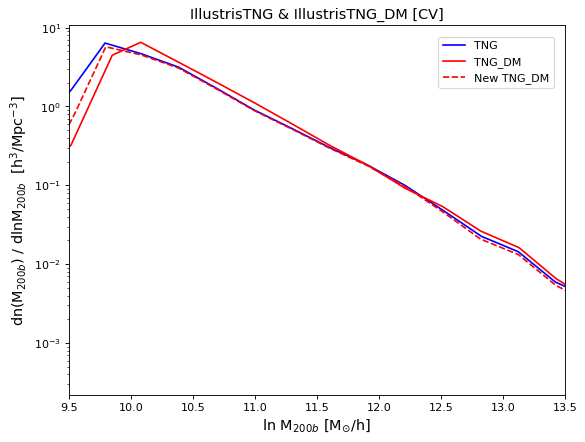

In [89]:
# Mass function dn(M)/dlnM plot all sim
volume = 25.00**3

logbin_bar = 1./(limits_hbar[1]-limits_hbar[0])/(num_mf_bins-1.)
norm_bar = (1./(np.log(10.)*logbin_bar*volume))

#logbin_DM = 1./(limits_DM[1]-limits_DM[0])/(num_mf_bins-1.)
#norm_DM = (1./(np.log(10.)*logbin_DM*volume))

pylab.figure(num = None, figsize = (8, 6), dpi=80, facecolor = 'w', edgecolor = 'k')
plt.xlim(left=9.5, right=13.5)
#plt.ylim(bottom=1e3, top=3e5) 
plt.plot(np.array(mfbinsmean_Hbar), np.array(countHbar*norm_bar), 'blue', linestyle='solid', label = "TNG")
plt.plot(np.array(mfbinsmean_Hdm), np.array(countHdm*norm_bar), 'red', linestyle='solid', label = "TNG_DM")
plt.plot(np.array(new_mfbinsmean_Hdm), np.array(new_countHdm*norm_bar), 'red', linestyle='--', label = "New TNG_DM")
#plt.plot(mfbinsmean, countSubhalos*norm, 'red', linestyle='solid', label = "Subhalos")
plt.title('IllustrisTNG & IllustrisTNG_DM [CV]', fontsize = 13)
plt.legend(loc = 0, borderaxespad = 1.)
plt.xlabel(r'ln M$_{200b}$ [M$_{\odot}$/h]', fontsize=13)
plt.ylabel(r'dn(M$_{200b}$) / dlnM$_{200b}$  [h$^3$/Mpc$^{-3}$]', fontsize=13)
#plt.xscale('log')
plt.yscale('log')
plt.savefig('HMF.png')
plt.show()

In [31]:
len(lnnewm200b)

5958

In [35]:
from haloscope import ConditionalMultiVariateGaussian 

In [ ]:
import array
halos_bar_all = data_bar[(data_bar.pid == -1)]
halos_dm_all = data_dm[(data_dm.pid == -1)]
print('all halos=',len(halos_bar_all))
#min_mass_hbar = halos_bar_all.M200b.min()
min_mass_hbar = 10**10
#max_mass_hbar = halos_bar_all.M200b.max()
max_mass_hbar = 10**11.6
mw_mass_i = np.log10(max_mass_hbar)
mw_mass_f = np.log10(10**12.6)
bin_4_i = mw_mass_f
bin_4_f = np.log10(halos_bar_all.M200b.max())
bin_4_f_10 = 10**bin_4_f
bin2_M_bar = [bin_4_i,bin_4_f]
print("%.4g"% min_mass_hbar,"%.4g"% bin_4_f_10)
nbins = 2
bins = np.arange(nbins)
del_logM_bar = np.asarray((np.log10(max_mass_hbar)-np.log10(min_mass_hbar))/nbins)
bins_M_bar = [np.log10(min_mass_hbar)]
name = []
for i in bins+1:
    bins_M_bar.append(np.log10(min_mass_hbar)+ i*del_logM_bar)
    name.append('halos_binM_bar'+'_'+str(i))
print(bins_M_bar,bin2_M_bar)
bins_M_bar = np.asarray(bins_M_bar+bin2_M_bar)
bins_M_bar_10 = np.asarray(10**bins_M_bar)
print(bins_M_bar)
font1 = {'color':  'red',
        'weight': 'normal',
        'size': 13,
        }
font2 = {'color':  'darkmagenta',
        'weight': 'normal',
        'size': 13,
        }
font3 = {'color':  'darkgreen',
        'weight': 'normal',
        'size': 13,
        }
font4 = {'color':  'black',
        'weight': 'normal',
        'size': 12.5,
        }
nbins = 3
bins = np.arange(nbins)
for i in bins:
    print(i,'Mass range:',"%.4g"% 10**bins_M_bar[i],"%.4g"% 10**bins_M_bar[i+1])
    halos_bar = halos_bar_all[(np.log10(halos_bar_all.M200b) >= bins_M_bar[i]) & (np.log10(halos_bar_all.M200b) < bins_M_bar[i+1])]               
    #halos_dm = halos_dm_all[(np.log10(halos_dm_all.M200b) >= bins_M_bar[i]) & (np.log10(halos_dm_all.M200b) < bins_M_bar[i+1])]               
    halos_dm = halos_dm_all[(np.log10(halos_dm_all.M200b02d) >= bins_M_bar[i]) & (np.log10(halos_dm_all.M200b02d) < bins_M_bar[i+1])]               
    print('# halos bar:',len(halos_bar),'# halos dm:',len(halos_dm))
    
    cg = ConditionalMultiVariateGaussian()
    x_train = np.asarray(halos_bar[['TidalForce']]) #np.random.randn(100000,2) ## this could be 100000 baryonified haloes with 2 input properties
    y_train = np.asarray(halos_bar[['cv','Spin','ca','ba']]) #np.random.randn(100000,3) ## this could be 100000 baryonified haloes with 3 output properties
    x_test  = np.asarray(halos_dm[['TidalForce']]) #np.random.randn(20000,2)   ## this could be 20000 dm haloes with 2 input properties


    print (x_train.shape)
    print (y_train.shape)
    cg.fit(x_train,y_train)
    y_pred = cg.predict(x_test)
    print(y_pred.shape)
    valy1,edge1,edge2 = np.histogram2d(halos_dm.cv, halos_dm.ba, bins=30, density = False)
    edgex = am(edge1)
    edgey = am(edge2)
    pylab.figure(num = None, figsize = (8, 6), dpi=80, facecolor = 'w', edgecolor = 'k')

    plt.plot(halos_bar.cv, halos_bar.ba,'.',label = "TNG CV")
    plt.plot(halos_dm.cv, halos_dm.ba,'.',label = "TNG_DM CV")
    #plt.text(0.18,80, [bins_M_bar[i],bins_M_bar[i+1]], fontsize=11, fontdict=font2)
    #plt.text(0.18,80,["M200b".format(bins_M_bar[i],bins_M_bar[i+1])])

    #plt.contour(edgex, edgey, valy1.T / np.sum(valy1), levels = 5, cmap = 'Purples')
    #plt.colorbar()

    lvl = confidence_intervals(valy1.T/valy1.sum())
    plt.contour(edgex, edgey,valy1.T/valy1.sum(),levels=lvl,cmap='Reds')
    plt.colorbar()

    plt.title('IllustrisTNG & IllustrisTNG_DM', fontsize = 13)
    plt.legend(loc = 0, borderaxespad = 1.)
    plt.xlabel('c', fontsize=13)
    plt.ylabel(r'$b/a$', fontsize=13)
    #plt.xscale('log')
    #plt.yscale('log')
    #fig.savefig('fig1.png')
    pylab.figure(num = None, figsize = (8, 6), dpi=80, facecolor = 'w', edgecolor = 'k')

    plt.plot(halos_bar.cv, halos_bar.Rvir,'.',label = "TNG CV")
    plt.plot(halos_dm.cv, halos_dm.Rvir,'.',label = "TNG_DM CV")

    plt.title('IllustrisTNG & IllustrisTNG_DM', fontsize = 13)
    plt.legend(loc = 0, borderaxespad = 1.)
    plt.xlabel('c', fontsize=13)
    plt.ylabel(r'$R_{vir}$', fontsize=13)
    bins = 15
    ##spin vs conc
    ca_range   = [0.25, 1.05]
    conc_range = [0.1, 30]
    ba_range   = [0.45, 1.05]
    spin_range = [0, 0.1]
    rvir_range = [120, 200]
    density    = False
    valy1,edge1,edge2 = np.histogram2d(halos_bar.Spin, halos_bar.cv, bins=bins, range = [ spin_range,conc_range],density=density)
    valx1,edge1,edge2 = np.histogram2d(halos_dm.Spin, halos_dm.cv, bins=bins, range = [ spin_range,conc_range],density=density)
    valp1,edge1,edge2 = np.histogram2d(y_pred[:,1], y_pred[:,0], bins=bins, range = [ spin_range,conc_range],density=density)
    edgex = am(edge1)
    edgey = am(edge2)
    #%print (edgey)

    ## vs c/a
    _2valy1,edge1,edge2 = np.histogram2d(halos_bar.Spin, halos_bar.ca, bins=bins, range = [ spin_range,ca_range],density=density)
    _2valx1,edge1,edge2 = np.histogram2d(halos_dm.Spin, halos_dm.ca, bins=bins, range = [ spin_range,ca_range],density=density)
    _2valp1,edge1,edge2 = np.histogram2d(y_pred[:,1], y_pred[:,2], bins=bins, range = [ spin_range,ca_range],density=density)
    _2edgex = am(edge1)
    _2edgey = am(edge2)
    #%


    _3valy1,edge1,edge2 = np.histogram2d(halos_bar.Spin, halos_bar.ba, bins=bins, range = [ spin_range,ba_range],density=density)
    _3valx1,edge1,edge2 = np.histogram2d(halos_dm.Spin, halos_dm.ba, bins=bins, range = [ spin_range,ba_range],density=density)
    _3valp1,edge1,edge2 = np.histogram2d(y_pred[:,1], y_pred[:,3], bins=bins, range = [ spin_range,ba_range],density=density)
    _3edgex = am(edge1)
    _3edgey = am(edge2)

    ## halo concentration vs c/a
    _4valy1,edge1,edge2 = np.histogram2d(halos_bar.cv, halos_bar.ca, bins=bins, range = [ conc_range,ca_range],density=density)
    _4valx1,edge1,edge2 = np.histogram2d(halos_dm.cv, halos_dm.ca, bins=bins, range = [ conc_range,ca_range],density=density)
    _4valp1,edge1,edge2 = np.histogram2d(y_pred[:,0], y_pred[:,2], bins=bins, range = [ conc_range,ca_range],density=density)
    _4edgex = am(edge1)
    _4edgey = am(edge2)

    ## halo concentration vs b/a
    _5valy1,edge1,edge2 = np.histogram2d(halos_bar.cv, halos_bar.ba, bins=bins, range = [ conc_range,ba_range],density=density)
    _5valx1,edge1,edge2 = np.histogram2d(halos_dm.cv, halos_dm.ba, bins=bins, range = [ conc_range,ba_range],density=density)
    _5valp1,edge1,edge2 = np.histogram2d(y_pred[:,0], y_pred[:,3], bins=bins, range = [ conc_range,ba_range],density=density)
    _5edgex = am(edge1)
    _5edgey = am(edge2)

    ## ca vs b/a
    _6valy1,edge1,edge2 = np.histogram2d(halos_bar.ca, halos_bar.ba, bins=bins, range = [ ca_range,ba_range],density=density)
    _6valx1,edge1,edge2 = np.histogram2d(halos_dm.ca, halos_dm.ba, bins=bins, range = [ ca_range,ba_range],density=density)
    _6valp1,edge1,edge2 = np.histogram2d(y_pred[:,2], y_pred[:,3], bins=bins, range = [ ca_range,ba_range],density=density)

    _6edgex = am(edge1)
    _6edgey = am(edge2)
    import matplotlib

    cmap = matplotlib.cm.get_cmap('Purples')
    colorp = [cmap(0.3), cmap(0.4),cmap(0.5),cmap(1.0)]
    colorpp = [cmap(0.3), cmap(0.4),cmap(0.5),cmap(0.9)]
    cmap = matplotlib.cm.get_cmap('binary')
    colorb = [ cmap(0.6),cmap(0.6),cmap(0.6),cmap(0.6)]
    #colorbb = [ cmap(0.6),cmap(0.6),cmap(0.6),cmap(0.6)]
    cmap = matplotlib.cm.get_cmap('Oranges')
    coloro = [cmap(0.3), cmap(0.5),cmap(0.7),cmap(0.8)]
    coloroo = [cmap(0.3), cmap(0.5),cmap(0.7),cmap(0.89)]

    #colorp = colorp[1:]
    #colorb = colorb[1:]
    #coloro = coloro[1:]

    def easyplot(valx,valy,valp,edgex,edgey,lrview=True,predview=True):
        alpha=0.26
        if lrview ==True:
            lvl = confidence_intervals(valx.T/valx.sum())
            ax.contourf(edgex,edgey,valx.T/valx.sum(),colors=colorp,levels=lvl,alpha=alpha)
            c1 = ax.contour(edgex,edgey,valx.T/valx.sum(),levels=lvl,colors=colorpp,linewidths=3)
            h1,l1 = c1.legend_elements()
        else:
            h1=None
        lvl = confidence_intervals(valy.T/valy.sum())
        ax.contourf(edgex,edgey,valy.T/valy.sum(),levels=lvl,colors=coloroo,alpha=alpha)
        c2 = ax.contour(edgex,edgey,valy.T/valy.sum(),levels=lvl,colors=coloro,linewidths=3)
        h2,l1 = c2.legend_elements()
        if predview == True:
            lvl = confidence_intervals(valp.T/valp.sum())
            CS = ax.contour(edgex,edgey,valp.T/valp.sum(),levels=lvl,colors=colorb,linewidths=4,linestyles='dashed')
            h3,l3 = CS.legend_elements()
            for c in CS.collections:
                c.set_dashes([(1,(3.0,3.0))])
        else:
            h3=None
        return h1,h2,h3
    ######################
    import time
    t = time.time()

    from matplotlib import pyplot as plt
    from matplotlib import ticker, cm
    #%from matplotlib import rc

    #%rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    #%rc('text', usetex=True)

    lvl = [0.0014,0.0028,0.0035,1]
    lvl = 3
    lvl = [0.0014,0.0028,0.01]
    #alpha=0.25

    vmax = 0.008
    vmaxcont = 0.005

    fig,axs  = plt.subplots(3,3,figsize=(15,15),gridspec_kw={ 'wspace':0,'hspace': 0},sharex='col',sharey='row')
    #ax = axs[0,0]
    axs[0, 2].axis('off')
    axs[0, 1].axis('off')
    axs[1, 2].set_visible(False)

    ax = axs[0,0]
    h1,h2,h3 = easyplot(valx1,valy1,valp1,edgex,edgey)
    axs[0,0].yaxis.set_ticks_position('both')
    axs[0,0].tick_params(axis='x', direction='in')
    axs[0,0].tick_params(axis='y', direction='in')
    axs[0,0].xaxis.set_ticks_position('both')
    axs[0,0].set_ylabel('Halo Concentration',fontsize=20)
    #1.29760000e+08 1.39624431e+10 1.50238762e+12 1.61660000e+14
    if i ==0:
        axs[0,0].text(1.5,0.3, '$ 10^{10} < M_{200b}/M_{\odot}h^{-1} < 6.3 \\times 10^{10}$', transform = axs[0,0].transAxes, fontsize = 25)
        axs[0,0].text(1.5,0.1, '$x_{train}$: Tidal Force', transform = axs[0,0].transAxes, fontsize = 25)

    if i ==1:
        axs[0,0].text(1.5,0.3, '$6.3 \\times 10^{10} < M_{200b}/M_{\odot}h^{-1} < 4 \\times 10^{11}$', transform = axs[0,0].transAxes, fontsize = 25)
        axs[0,0].text(1.5,0.1, '$x_{train}$: Tidal Force', transform = axs[0,0].transAxes, fontsize = 25)

    if i ==2:
        axs[0,0].text(1.5,0.3, '$4 \\times 10^{11} < M_{200b}/M_{\odot}h^{-1} < 4 \\times 10^{12}$', transform = axs[0,0].transAxes, fontsize = 25)
        axs[0,0].text(1.5,0.1, '$x_{train}$: Tidal Force', transform = axs[0,0].transAxes, fontsize = 25)

    if i ==3:
        axs[0,0].text(1.5,0.3, '$4 \\times 10^{12} < M_{200b}/M_{\odot}h^{-1} < 4 \\times 10^{14}$', transform = axs[0,0].transAxes, fontsize = 25)
        axs[0,0].text(1.5,0.1, '$x_{train}$: Tidal Force', transform = axs[0,0].transAxes, fontsize = 25)
          
    if h3 is not None:
        axs[0,0].legend([h1[-2], h2[-2],h3[-2]], ['Baryonic Haloes', 'DM Haloes','Our-Prediction (for DM haloes)'],fontsize=25,bbox_to_anchor=(3.05, 1))
    else:
        axs[0,0].legend([h1[-2], h2[-2]], ['Baryonic Haloes', 'DM Haloes'],fontsize=25,bbox_to_anchor=(3.05, 1))
        axs[0,0].text(2,0.5, '$2 \\times 10^{11} < M_{200}/M_{\odot}h^{-1} < 10^{12}$', transform = axs[0,0].transAxes, fontsize = 25)

    #axs[1, 0].contourf(_2edgex,_2edgey,_2valy.T/_2valy.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Oranges',alpha=alpha)
    #axs[1, 0].contour(_2edgex,_2edgey,_2valy.T/_2valy.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Oranges',linewidths=3)
    #axs[1, 0].contourf(_2edgex,_2edgey,_2valx.T/_2valx.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Purples',alpha=alpha)
    #axs[1, 0].contour(_2edgex,_2edgey,_2valx.T/_2valx.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Purples',linewidths=3)
    axs[1,0].set_ylabel('Halo Shape c/a',fontsize=20)
    #CS = axs[1, 0].contour(_2edgex,_2edgey,_2valp.T/_2valp.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='binary',linewidths=3.5,linestyles='dotted')
    ax = axs[1,0]
    easyplot(_2valx1,_2valy1,_2valp1,_2edgex,_2edgey)
    axs[1,0].yaxis.set_ticks_position('both')
    axs[1,0].tick_params(axis='x', direction='in')
    axs[1,0].tick_params(axis='y', direction='in')
    axs[1,0].xaxis.set_ticks_position('both')
    #for c in CS.collections:
    #    c.set_dashes([(11, (3.0, 3.0))])


    #axs[2, 0].contourf(_3edgex,_3edgey,_3valy.T/_3valy.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Oranges',alpha=alpha)
    #axs[2, 0].contour(_3edgex,_3edgey,_3valy.T/_3valy.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Oranges',linewidths=3)
    #axs[2, 0].contourf(_3edgex,_3edgey,_3valx.T/_3valx.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Purples',alpha=alpha)
    #axs[2, 0].contour(_3edgex,_3edgey,_3valx.T/_3valx.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Purples',linewidths=3)
    ax = axs[2,0]
    easyplot(_3valx1,_3valy1,_3valp1,_3edgex,_3edgey)
    axs[2,0].set_ylabel('Halo Shape b/a',fontsize=20)
    axs[2,0].yaxis.set_ticks_position('both')
    axs[2,0].tick_params(axis='x', direction='in')
    axs[2,0].tick_params(axis='y', direction='in')
    axs[2,0].xaxis.set_ticks_position('both')
    #CS = axs[2, 0].contour(_3edgex,_3edgey,_3valp.T/_3valp.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='binary',linewidths=3,linestyles='dotted')
    #for c in CS.collections:
    #    c.set_dashes([(11, (3.0, 3.0))])
    axs[2,0].set_xlabel('Halo Spin',fontsize=20)


    ## halo conc vs c/a
    #axs[1, 1].contourf(_4edgex,_4edgey,_4valy.T/_4valy.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Oranges',alpha=alpha)
    #axs[1, 1].contour(_4edgex,_4edgey,_4valy.T/_4valy.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Oranges',linewidths=3)
    #axs[1, 1].contourf(_4edgex,_4edgey,_4valx.T/_4valx.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Purples',alpha=alpha)
    #axs[1, 1].contour(_4edgex,_4edgey,_4valx.T/_4valx.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Purples',linewidths=3)
    ax = axs[1,1]
    easyplot(_4valx1,_4valy1,_4valp1,_4edgex,_4edgey)

    axs[1,1].yaxis.set_ticks_position('both')
    axs[1,1].tick_params(axis='x', direction='in')
    axs[1,1].tick_params(axis='y', direction='in')
    axs[1,1].xaxis.set_ticks_position('both')
    #CS = axs[1, 1].contour(_4edgex,_4edgey,_4valp.T/_4valp.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='binary',linewidths=3,linestyles='dotted')
    #for c in CS.collections:
    #    c.set_dashes([(11, (3.0, 3.0))])


    ## halo conc vs b/a
    #axs[2, 1].contourf(_5edgex,_5edgey,_5valy.T/_5valy.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Oranges',alpha=alpha)
    #axs[2, 1].contour(_5edgex,_5edgey,_5valy.T/_5valy.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Oranges',linewidths=3)
    #axs[2, 1].contourf(_5edgex,_5edgey,_5valx.T/_5valx.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Purples',alpha=alpha)
    #axs[2, 1].contour(_5edgex,_5edgey,_5valx.T/_5valx.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Purples',linewidths=3)
    axs[2,1].yaxis.set_ticks_position('both')
    axs[2,1].tick_params(axis='x', direction='in')
    axs[2,1].tick_params(axis='y', direction='in')
    axs[2,1].xaxis.set_ticks_position('both')
    #CS = axs[2, 1].contour(_5edgex,_5edgey,_5valp.T/_5valp.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='binary',linewidths=3,linestyles='dotted')
    #for c in CS.collections:
    #    c.set_dashes([(11, (3.0, 3.0))])
    axs[2, 1].set_xlabel('Halo Concentration',fontsize=20)
    ax = axs[2,1]
    easyplot(_5valx1,_5valy1,_5valp1,_5edgex,_5edgey)


    ## halo conc vs b/a
    #axs[2, 2].contourf(_6edgex,_6edgey,_6valy.T/_6valy.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Oranges',alpha=alpha)
    #axs[2, 2].contour(_6edgex,_6edgey,_6valy.T/_6valy.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Oranges',linewidths=3)
    #axs[2, 2].contourf(_6edgex,_6edgey,_6valx.T/_6valx.sum(),vmin=0,vmax=vmax,levels=lvl,cmap='Purples',alpha=alpha)
    #axs[2, 2].contour(_6edgex,_6edgey,_6valx.T/_6valx.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='Purples',linewidths=3)
    axs[2,2].yaxis.set_ticks_position('both')
    axs[2,2].tick_params(axis='x', direction='in')
    axs[2,2].tick_params(axis='y', direction='in')
    axs[2,2].xaxis.set_ticks_position('both')
    #CS = axs[2, 2].contour(_6edgex,_6edgey,_6valp.T/_6valp.sum(),vmin=0,vmax=vmaxcont,levels=lvl,cmap='binary',linewidths=3,linestyles='dotted')
    #for c in CS.collections:
    #    c.set_dashes([(11, (3.0, 3.0))])
    ax = axs[2,2]
    x = np.linspace(0, 1.1, 4)
    y = x
    plt.fill_between(x, y, where=(x > 0), color='grey', alpha=0.1)
    ax.set_xlim([0.3,1.05])
    ax.set_ylim([0.38,1.05])

    easyplot(_6valx1,_6valy1,_6valp1,_6edgex,_6edgey)


    axs[2, 2].set_xlabel('Halo Shape c/a',fontsize=20)
    #axs[0, 0].contourf(edgex,edgey,valp.T,vmin=0,vmax=1.5,levels=lvl,cmap='Purples',alpha=0.5)


    #plt.subplots_adjust(hspace=.0)
    #axs[0,0].grid()
    #axs[1,0].grid()
    #axs[1,1].grid()
    #axs[2,0].grid()
    #axs[2,1].grid()
    #axs[2,2].grid()
    #print (time.time()-t)

    plt.savefig('BarVsDM'+str(i)+'_TF_HMFDEX.pdf')
    
    
    #check dm halo concentrations
    meanHdms = stats.binned_statistic(np.log10(halos_dm.M200b02d),np.log10(halos_dm.M200b02d),statistic='mean', bins=11, range=(halos_bar.M200b.min(),halos_bar.M200b.max()))
    meanHdm = 10**meanHdms[0]
    cvmdms = stats.binned_statistic(np.log10(halos_dm.M200b02d),np.log10(halos_dm.cv),statistic='median', bins=11,range=(halos_bar.M200b.min(),halos_bar.M200b.max()))
    cvm_dm_sim = 10**cvmdms[0]
    cvmdms_pred = stats.binned_statistic(np.log10(halos_dm.M200b02d),np.log10(y_pred[:,0]),statistic='median', bins=11,range=(halos_bar.M200b.min(),halos_bar.M200b.max()))
    cvm_dm_pred = 10**cvmdms_pred[0]
    pylab.figure(num = None, figsize = (8, 6), dpi=80, facecolor = 'w', edgecolor = 'k')
    #plt.plot(halos_dm.M200b, halos_dm.cv,'.',label = "simulations")
    #plt.plot(halos_dm.M200b, y_pred[:,0],'.',label = "our-prediction")
    plt.plot(meanHdm, cvm_dm_sim,'-',label = "simulations")
    plt.plot(meanHdm, cvm_dm_pred,'-',label = "our-prediction")

In [ ]:
a =(10**9)*(10**0.1)
"%.4g"% a

In [ ]:
b= 10**(10.8)
"%.4g"% b

In [ ]:
nbins = 4
bins = np.arange(nbins)
bins

In [ ]:
halos_bar_all = data_bar[(data_bar.pid == -1)]
halos_dm_all = data_dm[(data_dm.pid == -1)]
print('all halos=',len(halos_bar_all))
min_mass_hbar = halos_bar_all.M200b.min()
#max_mass_hbar = halos_bar_all.M200b.max()
max_mass_hbar = 10**11.6
mw_mass_i = np.log10(max_mass_hbar)
mw_mass_f = np.log10(10**12.6)
bin_4_i = mw_mass_f
bin_4_f = np.log10(halos_bar_all.M200b.max())
bin_4_f_10 = 10**bin_4_f
bin2_M_bar = [bin_4_i,bin_4_f]
print("%.4g"% min_mass_hbar,"%.4g"% bin_4_f_10)
nbins = 2
bins = np.arange(nbins)
del_logM_bar = np.asarray((np.log10(max_mass_hbar)-np.log10(min_mass_hbar))/nbins)
bins_M_bar = [np.log10(min_mass_hbar)]
name = []
for i in bins+1:
    bins_M_bar.append(np.log10(min_mass_hbar)+ i*del_logM_bar)
    name.append('halos_binM_bar'+'_'+str(i))
print(bins_M_bar,bin2_M_bar)
bins_M_bar = np.asarray(bins_M_bar+bin2_M_bar)
bins_M_bar_10 = np.asarray(10**bins_M_bar)
print("%.4g"% bins_M_bar_10)

In [ ]:
"%.4g"% 10**9.85657041843354,"%.4g"% 10**11.6, "%.4g"% 10**12.6, "%.4g"% 10**14.208602574462532

In [ ]:
my_input = ['Engineering', 'Medical'] 
print(my_input)
input1 = [40, 30, 20, 10] 
my_input.extend(input1) 
print(my_input)